In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_pickle(r"C:\Projects\ACUTEVIS\260503_ACUTEVIS_dataset.pkl")


In [3]:
print(dataset.columns.levels)

calcium = dataset['suite2p']['roi_fluorescence']

spont = pd.DataFrame([calcium.loc['SB18'], calcium.loc['SB19'], calcium.loc['SB20']], index=['SB18', 'SB19', 'SB20'])

print(spont.keys())

[['encoder', 'notes', 'psychopy', 'pupil', 'pupil_meta', 'session_config', 'suite2p', 'time', 'timestamps', 'treadmill'], ['DOB', 'DOS', 'cell_identifier', 'cell_mask', 'click_delta', 'click_position', 'deltaf_f', 'device_elapsed_s', 'device_id', 'device_ts', 'distance_mm', 'duration', 'experiment_directory', 'experiment_id', 'experimentor', 'genotype', 'gratings_display_gratings.stopped', 'gratings_gratings_windows', 'gratings_gray_windows', 'gratings_stim_grating.started', 'gratings_stim_grating.stopped', 'gratings_stim_grayScreen.started', 'gratings_stim_grayScreen.stopped', 'gratings_trials.thisN', 'gratings_window_grating_start', 'gratings_window_grating_stop', 'gratings_window_gray_start', 'gratings_window_gray_stop', 'hardware_config_file', 'inj_vol', 'injection', 'meta', 'movies_description', 'movies_display_mov.started', 'movies_display_mov.stopped', 'movies_grey.started', 'movies_grey.stopped', 'movies_natural_mov.started', 'movies_thisRow.t', 'movies_trials.thisIndex', 'movi

In [4]:
def calculate_dff(arr):
    baseline = np.percentile(arr, 3, axis=0, keepdims=True)
    dff = (arr - baseline) / baseline
    return dff

spont_dff = spont.map(calculate_dff)

In [5]:
check = spont_dff['ses-04']['task-grayscreen']['SB20']
print(check)

np.isnan(check).sum()

[[11.361394  11.007216  11.314151  ...  8.224297   8.256933   8.5841465]
 [ 6.166195   6.047725   5.517747  ...  8.24667    7.9561706  8.226428 ]
 [ 5.3490047  5.767825   5.833338  ...  6.0239654  5.678157   5.88084  ]
 ...
 [ 4.2708955  4.1696215  4.4770727 ...  5.5478597  5.214708   5.722118 ]
 [ 8.729517   8.521012   8.45315   ...  7.2586346  7.6039376  7.691638 ]
 [ 2.4482763  2.4482763  2.4482763 ...  2.695135   2.6174042  3.0632198]]


np.int64(0)

In [6]:
def print_spont_shapes(df):
    for col in df.columns:
        for roi in df.index:
            val = df.loc[roi, col]
            shape = val.shape 
            print(f"{roi} | {col}: {shape}")

print_spont_shapes(spont_dff)


SB18 | ('ses-01', 'task-grayscreen'): (205, 36000)
SB19 | ('ses-01', 'task-grayscreen'): (231, 36000)
SB20 | ('ses-01', 'task-grayscreen'): (308, 36000)
SB18 | ('ses-02', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-02', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-02', 'task-grayscreen'): (144, 36000)
SB18 | ('ses-03', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-03', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-03', 'task-grayscreen'): (144, 36000)
SB18 | ('ses-04', 'task-grayscreen'): (88, 36000)
SB19 | ('ses-04', 'task-grayscreen'): (84, 36000)
SB20 | ('ses-04', 'task-grayscreen'): (144, 36000)


In [ ]:
plt.plot(np.mean(spont_dff['ses-04']['task-grayscreen']['SB18'], axis=0))
plt.show()
plt.plot(np.mean(spont_dff['ses-04']['task-grayscreen']['SB19'], axis=0))
plt.show()
plt.plot(np.mean(spont_dff['ses-04']['task-grayscreen']['SB20'], axis=0))
plt.show()

np.isnan(spont_dff['ses-04']['task-grayscreen']['SB20']).sum()


In [17]:
from scipy.signal import find_peaks

peaks_df = spont_dff.copy()
for col in spont_dff.columns:
    for subject in spont_dff.index:
        arr = spont_dff.loc[subject, col]  # shape: (n_rois, n_timepoints)
        peaks_df.loc[subject, col] = [find_peaks(trace, prominence=1.0)[0] for trace in arr]

print(peaks_df)


Session                                             ses-01  \
Task                                       task-grayscreen   
SB18     [[379, 490, 894, 981, 1080, 1808, 1840, 1861, ...   
SB19     [[432, 4041, 4494, 5196, 5209, 5214, 5252, 532...   
SB20     [[72, 157, 210, 274, 340, 354, 366, 505, 691, ...   

Session                                             ses-02  \
Task                                       task-grayscreen   
SB18     [[303, 704, 789, 824, 1103, 1238, 1301, 1537, ...   
SB19     [[1913, 3970, 4559, 4968, 7044, 7391, 11738, 1...   
SB20     [[67, 71, 77, 257, 580, 627, 690, 792, 1639, 1...   

Session                                             ses-03  \
Task                                       task-grayscreen   
SB18     [[7, 84, 144, 209, 501, 586, 705, 891, 1020, 1...   
SB19     [[18476, 18683, 18931, 25475, 31277, 34742, 35...   
SB20     [[69, 220, 610, 737, 899, 1277, 1351, 1529, 16...   

Session                                             ses-04  
Task  

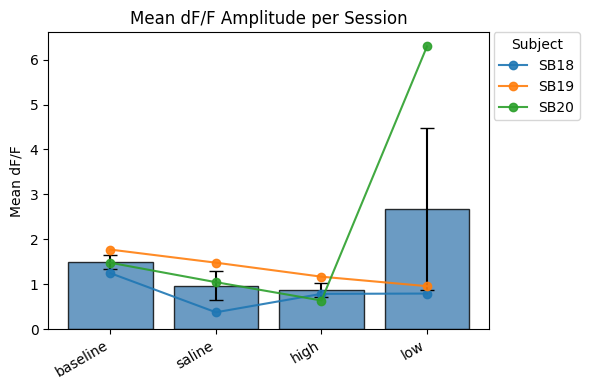

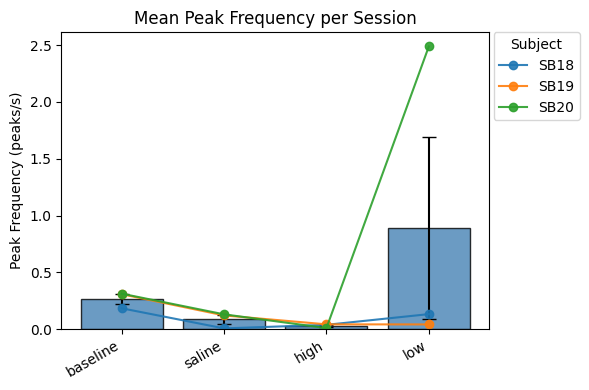

In [18]:
def get_injection_labels(dff_df, dataset):
    """Return injection label for each session column, using dataset.session_config.injection."""
    sc = dataset['session_config']['injection']
    labels = []
    for ses, _task in dff_df.columns:
        ses_vals = sc.xs(ses, level='Session')
        labels.append(ses_vals.iloc[0])
    return labels


def bar_plot(session_means, session_sems, session_labels, subject_values, subject_names, ylabel, title):
    """Bar plot: mean ± SEM bars with individual subject dots connected across sessions."""
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(session_labels))
    ax.bar(x, session_means, yerr=session_sems, capsize=5,
           color='steelblue', edgecolor='black', alpha=0.8)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    subject_values_arr = np.array(subject_values)  # (n_sessions, n_subjects)
    for i_subj in range(subject_values_arr.shape[1]):
        vals = subject_values_arr[:, i_subj]
        color = colors[i_subj % len(colors)]
        ax.plot(x, vals, marker='o', color=color, linewidth=1.5, markersize=6,
                alpha=0.9, label=subject_names[i_subj])
    ax.set_xticks(x)
    ax.set_xticklabels(session_labels, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Subject', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()


def plot_mean_dff_amplitude(dff_df, dataset):
    """Bar plot of mean dF/F amplitude per session, labelled by injection identity."""
    sessions = dff_df.columns.get_level_values('Session').unique()
    inj_labels = get_injection_labels(dff_df, dataset)
    session_means, session_sems, all_subject_vals = [], [], []
    for ses in sessions:
        ses_cols = [c for c in dff_df.columns if c[0] == ses]
        subject_means = [
            np.nanmean([np.nanmean(dff_df.loc[subject, col]) for col in ses_cols])
            for subject in dff_df.index
        ]
        session_means.append(np.mean(subject_means))
        session_sems.append(np.std(subject_means, ddof=1) / np.sqrt(len(subject_means)))
        all_subject_vals.append(subject_means)
    bar_plot(session_means, session_sems, inj_labels, all_subject_vals,
             list(dff_df.index), ylabel='Mean dF/F', title='Mean dF/F Amplitude per Session')


def plot_mean_peak_frequency(pk_df, dff_df, dataset, fs=30.0):
    """Bar plot of mean peak frequency (peaks/s) per session, labelled by injection identity."""
    sessions = pk_df.columns.get_level_values('Session').unique()
    inj_labels = get_injection_labels(dff_df, dataset)
    session_means, session_sems, all_subject_vals = [], [], []
    for ses in sessions:
        ses_cols = [c for c in pk_df.columns if c[0] == ses]
        subject_means = []
        for subject in pk_df.index:
            roi_freqs = []
            for col in ses_cols:
                n_timepoints = dff_df.loc[subject, col].shape[1]
                duration_s = n_timepoints / fs
                roi_freqs.extend(len(p) / duration_s for p in pk_df.loc[subject, col])
            subject_means.append(np.mean(roi_freqs))
        session_means.append(np.mean(subject_means))
        session_sems.append(np.std(subject_means, ddof=1) / np.sqrt(len(subject_means)))
        all_subject_vals.append(subject_means)
    bar_plot(session_means, session_sems, inj_labels, all_subject_vals,
             list(pk_df.index), ylabel='Peak Frequency (peaks/s)', title='Mean Peak Frequency per Session')


# --- Call both plots ---
plot_mean_dff_amplitude(spont_dff, dataset)
plot_mean_peak_frequency(peaks_df, spont_dff, dataset, fs=30.0)


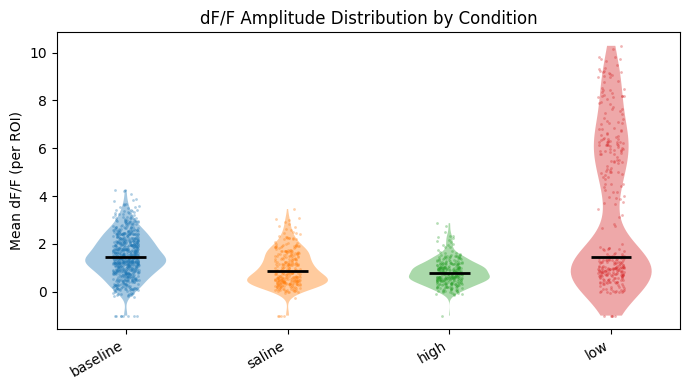

In [20]:
def plot_dff_violin(dff_df, dataset):
    """Violin plot of per-ROI mean dF/F amplitude, grouped by injection condition."""
    sc = dataset['session_config']['injection']
    rng = np.random.default_rng(0)

    condition_order = []
    data_by_condition = {}
    for ses, task in dff_df.columns:
        condition = sc.xs(ses, level='Session').iloc[0]
        if condition not in data_by_condition:
            data_by_condition[condition] = []
            condition_order.append(condition)
        for subject in dff_df.index:
            arr = dff_df.loc[subject, (ses, task)]  # (n_rois, n_timepoints)
            roi_means = np.nanmean(arr, axis=1)     # mean over time per ROI
            data_by_condition[condition].extend(roi_means.tolist())

    conditions = list(dict.fromkeys(condition_order))
    plot_data = [data_by_condition[c] for c in conditions]

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    parts = ax.violinplot(plot_data, positions=np.arange(len(conditions)),
                          showmedians=True, showextrema=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i % len(colors)])
        pc.set_alpha(0.4)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    # Jittered individual ROI dots
    for i, (vals, color) in enumerate(zip(plot_data, colors)):
        vals = np.array(vals)
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, s=4, color=color, alpha=0.35, linewidths=0)

    ax.set_xticks(np.arange(len(conditions)))
    ax.set_xticklabels(conditions, rotation=30, ha='right')
    ax.set_ylabel('Mean dF/F (per ROI)')
    ax.set_title('dF/F Amplitude Distribution by Condition')
    plt.tight_layout()
    plt.show()


plot_dff_violin(spont_dff, dataset)


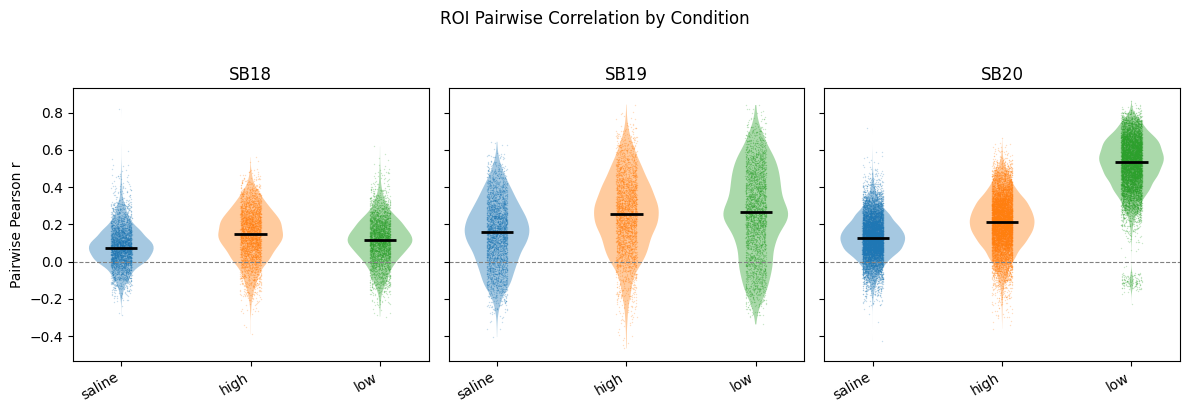

In [23]:
def compute_pairwise_correlations(dff_df, dataset, conditions=('saline', 'high', 'low')):
    """
    For each target condition and subject, compute the pairwise Pearson correlation
    matrix across all ROI dF/F traces and return the upper-triangle values.

    Returns a dict: {condition: {subject: 1-D array of pairwise r values}}
    """
    sc = dataset['session_config']['injection']
    results = {c: {} for c in conditions}

    for ses, task in dff_df.columns:
        condition = sc.xs(ses, level='Session').iloc[0]
        if condition not in conditions:
            continue
        for subject in dff_df.index:
            arr = dff_df.loc[subject, (ses, task)]  # (n_rois, n_timepoints)
            # Drop ROIs with any NaN
            no_nan = arr[~np.isnan(arr).any(axis=1)]
            # Drop zero-variance ROIs (would produce NaN in corrcoef)
            valid = no_nan[no_nan.std(axis=1) > 0]
            if valid.shape[0] < 2:
                print(f"  Skipping {subject} / {condition}: only {valid.shape[0]} valid ROI(s)")
                results[condition][subject] = np.array([])
                continue
            corr = np.corrcoef(valid)
            triu_idx = np.triu_indices_from(corr, k=1)
            results[condition][subject] = corr[triu_idx]

    return results


def plot_pairwise_correlations(corr_results):
    """
    One subplot per subject. Each subplot shows a violin + jitter per condition.
    """
    conditions = list(corr_results.keys())
    all_subjects = sorted({s for vals in corr_results.values() for s in vals})
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    cond_colors = [colors[i % len(colors)] for i in range(len(conditions))]
    rng = np.random.default_rng(1)

    fig, axes = plt.subplots(1, len(all_subjects), figsize=(4 * len(all_subjects), 4),
                             sharey=True)
    if len(all_subjects) == 1:
        axes = [axes]

    for ax, subject in zip(axes, all_subjects):
        plot_data = []
        for cond in conditions:
            r_vals = corr_results[cond].get(subject, np.array([]))
            plot_data.append(r_vals)

        # Only pass non-empty arrays to violinplot
        valid_idx = [i for i, v in enumerate(plot_data) if len(v) > 1]
        if valid_idx:
            parts = ax.violinplot([plot_data[i] for i in valid_idx],
                                  positions=valid_idx,
                                  showmedians=True, showextrema=False)
            for j, pc in enumerate(parts['bodies']):
                pc.set_facecolor(cond_colors[valid_idx[j]])
                pc.set_alpha(0.4)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)

        for i, (vals, color) in enumerate(zip(plot_data, cond_colors)):
            if len(vals) == 0:
                continue
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax.scatter(i + jitter, vals, s=1, color=color, alpha=0.25, linewidths=0)

        ax.set_xticks(np.arange(len(conditions)))
        ax.set_xticklabels(conditions, rotation=30, ha='right')
        ax.set_title(subject)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

    axes[0].set_ylabel('Pairwise Pearson r')
    fig.suptitle('ROI Pairwise Correlation by Condition', y=1.02)
    plt.tight_layout()
    plt.show()


corr_results = compute_pairwise_correlations(spont_dff, dataset)
plot_pairwise_correlations(corr_results)


In [145]:
# Phase 1: Total NaN count per subject across all sessions
for subject in spont.index:
    total_nans = 0
    for col in spont.columns:
        arr = spont.loc[subject, col]
        if hasattr(arr, 'shape'):
            total_nans += int(np.isnan(arr).sum())
    print(f"{subject}: total NaN values = {total_nans}")


SB18: total NaN values = 0
SB19: total NaN values = 0
SB20: total NaN values = 0


In [124]:
# Phase 2: Which neurons are affected for SB20 — NaN density per session
subject = 'SB20'
for col in spont.columns:
    arr = spont.loc[subject, col]
    if hasattr(arr, 'shape') and arr.ndim == 2:
        nan_neurons = int(np.isnan(arr).any(axis=1).sum())
        total_neurons = arr.shape[0]
        nan_timepoints = int(np.isnan(arr).any(axis=0).sum())
        total_timepoints = arr.shape[1]
        print(f"{col}: {nan_neurons}/{total_neurons} neurons with NaN | {nan_timepoints}/{total_timepoints} timepoints with NaN")


('ses-01', 'task-grayscreen'): 0/308 neurons with NaN | 0/36000 timepoints with NaN
('ses-02', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN
('ses-03', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN
('ses-04', 'task-grayscreen'): 0/144 neurons with NaN | 0/36000 timepoints with NaN


In [125]:
# Phase 3: Check raw calcium source for SB20 — does NaN come from the dataset itself?
raw_sb20 = calcium.loc['SB20']
for col in raw_sb20.index:
    arr = raw_sb20[col]
    if hasattr(arr, 'shape'):
        n_nan = int(np.isnan(arr).sum())
        print(f"SB20 | {col}: {n_nan} NaN values, shape={arr.shape}")


SB20 | ('ses-01', 'task-grayscreen'): 0 NaN values, shape=(308, 36000)
SB20 | ('ses-02', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)
SB20 | ('ses-03', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)
SB20 | ('ses-04', 'task-grayscreen'): 0 NaN values, shape=(144, 36000)


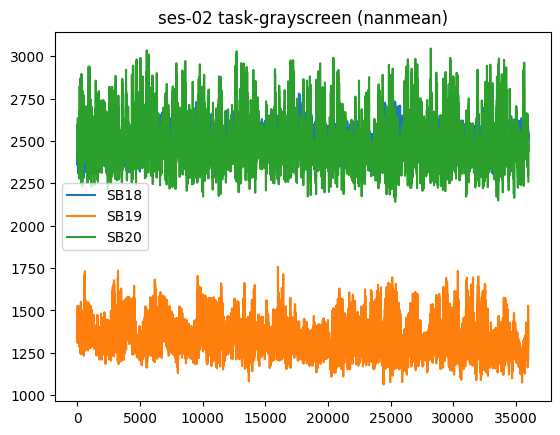

In [144]:
# Workaround: np.nanmean skips NaN — use this while diagnosing
for subject in spont.index:
    plt.plot(np.nanmean(spont['ses-02']['task-grayscreen'][subject], axis=0), label=subject)
plt.legend()
plt.title("ses-02 task-grayscreen (nanmean)")
plt.show()
